# Gradient Accumulation High-Batch Experiment (Full)

Bu notebook sadece **gradient accumulation** ile kucuk+büyük effective batch size degerlerini dener ve karsilastirma raporu uretir.

## 1. Ortam Kurulumu ve Importlar

Bu hucre proje kokunu bulur, `gradient_accumulation` yolunu `sys.path` icine alir, gerekli kutuphaneleri import eder ve **dogru train modulu** yuklenmis mi kontrol eder.

In [1]:
from pathlib import Path
import os
import sys
import json
import random
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

sns.set_theme(style="whitegrid")

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for parent in [current, *current.parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("Project root not found (no .git folder).")

PROJECT_ROOT = find_project_root()
GA_PATH = (PROJECT_ROOT / "gradient_accumulation").resolve()
if str(GA_PATH) not in sys.path:
    sys.path.insert(0, str(GA_PATH))

from functions.dataset import (
    COVIDCXNetDataset,
    DataLoaderConfig,
    build_transforms,
    create_dataloader,
)
from functions.train import TrainConfig, fit
import functions.train as train_module

expected_train_path = (GA_PATH / "functions" / "train.py").resolve()
actual_train_path = Path(train_module.__file__).resolve()
assert actual_train_path == expected_train_path, (
    f"Wrong train module imported. Expected: {expected_train_path}, got: {actual_train_path}"
)
print(f"[OK] Imported train module from: {actual_train_path}")

[OK] Imported train module from: D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py


## 2. Konfigurasyon ve Profil Secimi

Bu hucre JSON config dosyasini okur, `full` profilini aktif eder, cihaz secimini yapar ve calisacak EBS listesini ekrana yazar.

In [2]:
PROFILE_NAME = "full"
CONFIG_PATH = Path("./configs/gradient_accumulation_experiment.json")

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    CONFIG = json.load(f)

PROFILE = CONFIG["profiles"][PROFILE_NAME]
RUNS_ROOT = Path(CONFIG["runs_root"])
if not RUNS_ROOT.is_absolute():
    RUNS_ROOT = (PROJECT_ROOT / RUNS_ROOT).resolve()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Profile: {PROFILE_NAME}")
print(f"Device: {device}")
print(f"Runs root: {RUNS_ROOT}")
print(f"Model: {CONFIG['model_name']}")
print(f"Effective batch sizes: {PROFILE['effective_batch_sizes']}")

Profile: full
Device: cuda
Runs root: D:\Projects\ML_Algorithms\batchsize\runs\gradient_accumulation_compare
Model: resnet50
Effective batch sizes: [128, 256, 512, 1024, 2048, 4096, 8192]


## 3. Reproducibility (Seed Ayarlari)

Bu hucre onceki batch size calismasiyla ayni seed duzenini uygular (`random`, `numpy`, `torch`, `cudnn`). Boylece kosular arasi tekrar edilebilirlik korunur.

In [3]:
def set_seed_like_previous_experiment(seed: int, deterministic: bool = True) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = bool(deterministic)
    torch.backends.cudnn.benchmark = not bool(deterministic)

set_seed_like_previous_experiment(CONFIG["seed"], CONFIG["deterministic"])
print("[OK] Seeds configured like batch_size_experiment_notebook.ipynb")

[OK] Seeds configured like batch_size_experiment_notebook.ipynb


## 4. Veri Seti Hazirlama

Bu hucre train/validation transformlarini kurar, `COVIDCXNetDataset` nesnelerini olusturur ve val split adaylarini sirasiyla deneyip uygun olanini secer.

In [4]:
train_transform = build_transforms(image_size=CONFIG["image_size"], augment=True)
eval_transform = build_transforms(image_size=CONFIG["image_size"], augment=False)

train_dataset = COVIDCXNetDataset(
    csv_file=CONFIG["data_csv_file"],
    root_dir=CONFIG["data_root_dir"],
    transform=train_transform,
    split="train",
)

val_dataset = None
selected_val_split = None
for split_name in CONFIG["val_split_candidates"]:
    try:
        val_dataset = COVIDCXNetDataset(
            csv_file=CONFIG["data_csv_file"],
            root_dir=CONFIG["data_root_dir"],
            transform=eval_transform,
            split=split_name,
        )
        selected_val_split = split_name
        break
    except ValueError:
        continue

if val_dataset is None:
    raise ValueError("No validation split found in configured candidates.")

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)} (split={selected_val_split})")

Train samples: 53691
Val samples: 4186 (split=val)


## 5. Accumulation Kosularini Calistirma

Bu hucre ResNet50 modelini kurar, her effective batch size icin `accumulation_steps` hesaplar, egitimi calistirir ve kosu bazli metrikleri tek bir `comparison_df` tablosunda toplar.

In [5]:
def build_resnet50(num_classes: int) -> nn.Module:
    try:
        model = models.resnet50(weights="DEFAULT")
    except Exception:
        model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def run_single_accumulation(effective_batch_size: int) -> dict:
    micro_batch_size = int(PROFILE["micro_batch_size"])

    if effective_batch_size % micro_batch_size != 0:
        return {
            "effective_batch_size": effective_batch_size,
            "micro_batch_size": micro_batch_size,
            "accumulation_steps": None,
            "status": "invalid_config",
            "error": "effective_batch_size is not divisible by micro_batch_size",
        }

    accumulation_steps = effective_batch_size // micro_batch_size
    run_name = f"ga_resnet50_mb{micro_batch_size}_ebs{effective_batch_size}_acc{accumulation_steps}_{PROFILE_NAME}"

    train_loader = create_dataloader(
        train_dataset,
        DataLoaderConfig(
            batch_size=micro_batch_size,
            shuffle=True,
            num_workers=CONFIG["num_workers"],
            drop_last=False,
        ),
        device=device,
    )
    val_loader = create_dataloader(
        val_dataset,
        DataLoaderConfig(
            batch_size=micro_batch_size,
            shuffle=False,
            num_workers=CONFIG["num_workers"],
            drop_last=False,
        ),
        device=device,
    )

    model = build_resnet50(CONFIG["num_classes"])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=float(CONFIG["optimizer"]["lr"]))

    train_cfg = TrainConfig(
        num_epochs=int(PROFILE["num_epochs"]),
        accumulation_steps=int(accumulation_steps),
        patience=3,
        run_name=run_name,
        output_dir=str(RUNS_ROOT),
        log_every_n_steps=10,
        system_log_interval=50,
        save_best=True,
    )

    try:
        result = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            config=train_cfg,
            logger=None,
            show_progress=True,
        )

        run_dir = Path(result.run_dir)
        epoch_df = pd.read_csv(run_dir / "epoch_metrics.csv")
        system_df = pd.read_csv(run_dir / "system_metrics.csv")
        summary = pd.read_json(run_dir / "run_summary.json", typ="series")

        val_epoch = epoch_df[epoch_df["phase"] == "val"]
        train_epoch = epoch_df[epoch_df["phase"] == "train"]

        return {
            "effective_batch_size": effective_batch_size,
            "micro_batch_size": micro_batch_size,
            "accumulation_steps": accumulation_steps,
            "status": "success",
            "run_name": run_name,
            "run_dir": str(run_dir),
            "best_val_loss": summary.get("best_val_loss", np.nan),
            "final_val_acc": (val_epoch["accuracy"].iloc[-1] if len(val_epoch) else np.nan),
            "total_train_time_sec": summary.get("total_train_time_sec", np.nan),
            "peak_vram_mb": (train_epoch["peak_vram_mb"].max() if len(train_epoch) else np.nan),
            "avg_samples_per_sec": (train_epoch["samples_per_sec"].mean() if len(train_epoch) else np.nan),
            "error": None,
        }
    except torch.cuda.OutOfMemoryError:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return {
            "effective_batch_size": effective_batch_size,
            "micro_batch_size": micro_batch_size,
            "accumulation_steps": accumulation_steps,
            "status": "oom",
            "error": "CUDA OOM",
        }
    except Exception as e:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        return {
            "effective_batch_size": effective_batch_size,
            "micro_batch_size": micro_batch_size,
            "accumulation_steps": accumulation_steps,
            "status": "failed",
            "error": f"{type(e).__name__}: {e}",
            "traceback": traceback.format_exc(limit=5),
        }

comparison_rows = []
for ebs in PROFILE["effective_batch_sizes"]:
    print(f"\n[RUN] effective_batch_size={ebs}")
    row = run_single_accumulation(int(ebs))
    comparison_rows.append(row)
    print(f" -> status={row['status']}")

comparison_df = pd.DataFrame(comparison_rows)
comparison_df


[RUN] effective_batch_size=128


D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
[2026-02-28 02:04:08] Run 'ga_resnet50_mb64_ebs128_acc2_full' started | epochs=5, accumulation_steps=2, amp=True
Epoch 1 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
[2026-02-28 02:06:39] Epoch 1/5 | train_loss=0.1186, train_acc=0.9583, val_loss=0.1204, val_acc=0.9625, epoch_time=121.66s, train_sps=441.33, peak_vram=3181.59MB
Epoch 2 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. P

 -> status=success

[RUN] effective_batch_size=256


D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
[2026-02-28 02:13:37] Run 'ga_resnet50_mb64_ebs256_acc4_full' started | epochs=5, accumulation_steps=4, amp=True
Epoch 1 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
[2026-02-28 02:15:58] Epoch 1/5 | train_loss=0.1343, train_acc=0.9548, val_loss=0.1177, val_acc=0.9613, epoch_time=115.83s, train_sps=463.54, peak_vram=3178.59MB
Epoch 2 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. P

 -> status=success

[RUN] effective_batch_size=512


...

D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
[2026-02-28 02:50:21] Run 'ga_resnet50_mb64_ebs4096_acc64_full' started | epochs=5, accumulation_steps=64, amp=True
Epoch 1 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
[2026-02-28 02:52:41] Epoch 1/5 | train_loss=0.4017, train_acc=0.8437, val_loss=0.2097, val_acc=0.9209, epoch_time=115.08s, train_sps=466.57, peak_vram=3266.39MB
Epoch 2 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated

 -> status=success

[RUN] effective_batch_size=8192


D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:318: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=amp_enabled)
[2026-02-28 02:59:29] Run 'ga_resnet50_mb64_ebs8192_acc128_full' started | epochs=5, accumulation_steps=128, amp=True
Epoch 1 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=amp_enabled):
[2026-02-28 03:01:51] Epoch 1/5 | train_loss=0.5331, train_acc=0.7926, val_loss=0.3521, val_acc=0.8636, epoch_time=115.09s, train_sps=466.50, peak_vram=3269.27MB
Epoch 2 [train]:   0%|          | 0/839 [00:00<?, ?it/s]D:\Projects\ML_Algorithms\gradient_accumulation\functions\train.py:170: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecat

 -> status=success


,effective_batch_size,micro_batch_size,accumulation_steps,status,run_name,run_dir,best_val_loss,final_val_acc,total_train_time_sec,peak_vram_mb,avg_samples_per_sec,error
0,128,64,2,success,ga_resnet50_mb64_ebs128_acc2_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.108513,0.964405,567.277194,3181.587402,526.867032,None
1,256,64,4,success,ga_resnet50_mb64_ebs256_acc4_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.108326,0.966077,549.330036,3178.587402,540.521560,None
2,512,64,8,success,ga_resnet50_mb64_ebs512_acc8_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.103982,0.965839,549.796664,3270.765137,542.990201,None
3,1024,64,16,success,ga_resnet50_mb64_ebs1024_acc16_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.106305,0.967511,548.704684,3266.390137,541.580915,None
4,2048,64,32,success,ga_resnet50_mb64_ebs2048_acc32_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.101840,0.969900,548.876055,3266.390137,542.665967,None
5,4096,64,64,success,ga_resnet50_mb64_ebs4096_acc64_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.122123,0.963927,547.085517,3266.390137,543.284883,None
6,8192,64,128,success,ga_resnet50_mb64_ebs8192_acc128_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.138749,0.959150,548.511836,3269.265137,543.379219,None


## 6. Karsilastirma Raporunu Kaydetme

Bu hucre olusan karsilastirma tablosunu diske yazar: `full_comparison.csv` ve `full_comparison.md` dosyalari uretilir.

In [7]:
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
comparison_csv = RUNS_ROOT / "full_comparison.csv"
comparison_md = RUNS_ROOT / "full_comparison.md"

comparison_df.sort_values(by="effective_batch_size", inplace=True, na_position="last")
comparison_df.to_csv(comparison_csv, index=False)
comparison_md.write_text(comparison_df.to_markdown(index=False), encoding="utf-8")

print(f"[OK] Saved CSV: {comparison_csv}")
print(f"[OK] Saved Markdown: {comparison_md}")
comparison_df

[OK] Saved CSV: D:\Projects\ML_Algorithms\batchsize\runs\gradient_accumulation_compare\full_comparison.csv
[OK] Saved Markdown: D:\Projects\ML_Algorithms\batchsize\runs\gradient_accumulation_compare\full_comparison.md


,effective_batch_size,micro_batch_size,accumulation_steps,status,run_name,run_dir,best_val_loss,final_val_acc,total_train_time_sec,peak_vram_mb,avg_samples_per_sec,error
0,128,64,2,success,ga_resnet50_mb64_ebs128_acc2_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.108513,0.964405,567.277194,3181.587402,526.867032,None
1,256,64,4,success,ga_resnet50_mb64_ebs256_acc4_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.108326,0.966077,549.330036,3178.587402,540.521560,None
2,512,64,8,success,ga_resnet50_mb64_ebs512_acc8_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.103982,0.965839,549.796664,3270.765137,542.990201,None
3,1024,64,16,success,ga_resnet50_mb64_ebs1024_acc16_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.106305,0.967511,548.704684,3266.390137,541.580915,None
4,2048,64,32,success,ga_resnet50_mb64_ebs2048_acc32_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.101840,0.969900,548.876055,3266.390137,542.665967,None
5,4096,64,64,success,ga_resnet50_mb64_ebs4096_acc64_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.122123,0.963927,547.085517,3266.390137,543.284883,None
6,8192,64,128,success,ga_resnet50_mb64_ebs8192_acc128_full,D:\Projects\ML_Algorithms\batchsize\runs\gradi...,0.138749,0.959150,548.511836,3269.265137,543.379219,None


## 7. Sonuclarin Gorsellestirilmesi

Bu hucre basarili kosular icin 4 ana grafigi cizer: best val loss, final val accuracy, toplam sure ve peak VRAM karsilastirmalari.

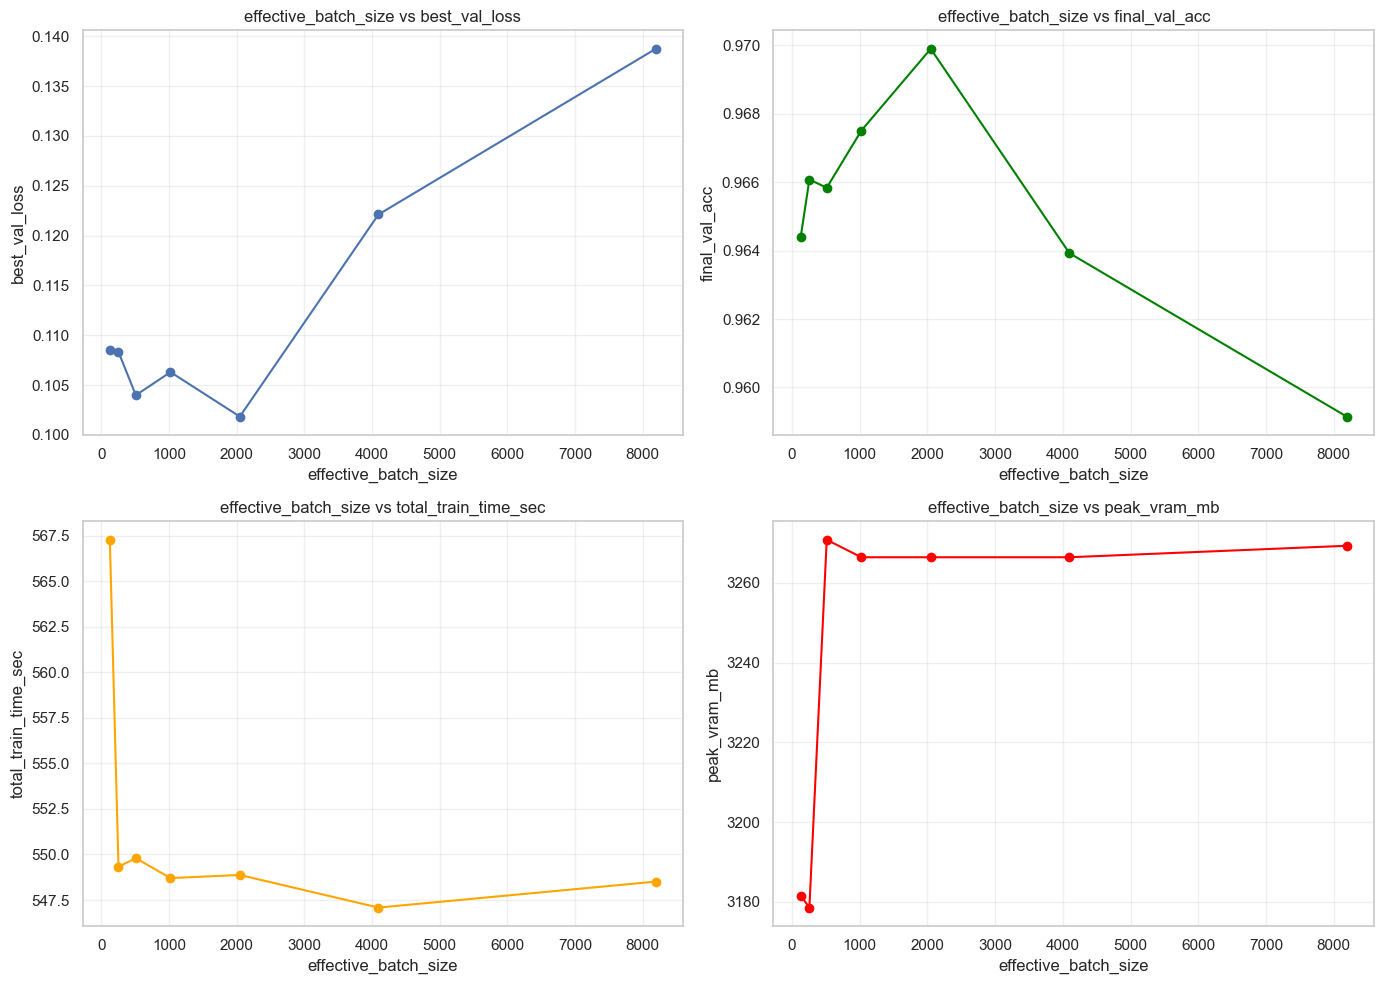

In [8]:
plot_df = comparison_df[comparison_df["status"] == "success"].copy()
if len(plot_df) == 0:
    raise ValueError("No successful runs to plot.")

plot_df = plot_df.sort_values("effective_batch_size")
x = plot_df["effective_batch_size"].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(x, plot_df["best_val_loss"], marker="o")
axes[0, 0].set_title("effective_batch_size vs best_val_loss")
axes[0, 0].set_xlabel("effective_batch_size")
axes[0, 0].set_ylabel("best_val_loss")

axes[0, 1].plot(x, plot_df["final_val_acc"], marker="o", color="green")
axes[0, 1].set_title("effective_batch_size vs final_val_acc")
axes[0, 1].set_xlabel("effective_batch_size")
axes[0, 1].set_ylabel("final_val_acc")

axes[1, 0].plot(x, plot_df["total_train_time_sec"], marker="o", color="orange")
axes[1, 0].set_title("effective_batch_size vs total_train_time_sec")
axes[1, 0].set_xlabel("effective_batch_size")
axes[1, 0].set_ylabel("total_train_time_sec")

axes[1, 1].plot(x, plot_df["peak_vram_mb"], marker="o", color="red")
axes[1, 1].set_title("effective_batch_size vs peak_vram_mb")
axes[1, 1].set_xlabel("effective_batch_size")
axes[1, 1].set_ylabel("peak_vram_mb")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notes

- Bu notebook standart batch training kosusu calistirmaz.
- Sadece accumulation bazli kucuk+büyük EBS karsilastirmasi yapar.
- Konfig degisikligi icin sadece JSON dosyasini guncellemek yeterlidir.